# Task 09: Model Optimization and Hyperparameter Tuning

## Optimized Client Retention Prediction using Logistic Regression

This project focuses on improving and validating a Client Retention Prediction model through Hyperparameter Tuning and Model Optimization techniques.

The best-performing model from the previous task, Logistic Regression, was selected and optimized using GridSearchCV. The project also includes Cross-Validation, Feature Importance Analysis, Learning Curve Evaluation, and Model Comparison to assess performance and reliability.

The objective is to develop a robust machine learning model capable of accurately predicting customer retention behavior.

# Import Libraries

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load Dataset

In [23]:
df = pd.read_csv(
    "coretech_client_retention.csv"
)

df.head()

,Client_ID,Monthly_Spend,Support_Tickets,Contract_Length,Service_Usage,Customer_Satisfaction,Renewal_History,Client_Status
0,2001,960,12,4,76,78,0,At_Risk
1,2002,3872,19,25,96,70,2,At_Risk
2,2003,3192,14,3,21,57,0,Churned
3,2004,566,2,32,29,75,3,At_Risk
4,2005,4526,7,3,14,41,1,Churned


### Dataset Interpretation

The dataset contains customer retention information and business-related features that can influence client behavior. Understanding the dataset structure is important before developing and optimizing machine learning models.

# Dataset Overview

In [24]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client_ID              350 non-null    int64 
 1   Monthly_Spend          350 non-null    int64 
 2   Support_Tickets        350 non-null    int64 
 3   Contract_Length        350 non-null    int64 
 4   Service_Usage          350 non-null    int64 
 5   Customer_Satisfaction  350 non-null    int64 
 6   Renewal_History        350 non-null    int64 
 7   Client_Status          350 non-null    object
dtypes: int64(7), object(1)
memory usage: 22.0+ KB


,Client_ID,Monthly_Spend,Support_Tickets,Contract_Length,Service_Usage,Customer_Satisfaction,Renewal_History
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,2175.500000,2603.845714,9.502857,17.868571,54.151429,68.765714,1.991429
std,101.180532,1389.773414,5.921041,10.385679,25.543321,16.971474,1.441281
min,2001.000000,104.000000,0.000000,1.000000,10.000000,40.000000,0.000000
25%,2088.250000,1393.250000,4.000000,8.000000,33.250000,54.000000,1.000000
50%,2175.500000,2712.500000,10.000000,19.000000,53.000000,68.000000,2.000000
75%,2262.750000,3715.750000,15.000000,27.000000,74.750000,83.000000,3.000000
max,2350.000000,4993.000000,19.000000,35.000000,99.000000,99.000000,4.000000


# Feature Selection

In [25]:
X = df[
    [
        "Monthly_Spend",
        "Support_Tickets",
        "Contract_Length",
        "Service_Usage",
        "Customer_Satisfaction",
        "Renewal_History"
    ]
]

encoder = LabelEncoder()

y = encoder.fit_transform(
    df["Client_Status"]
)

### Feature Selection Analysis

Relevant customer engagement and business performance features were selected to predict retention outcomes. These variables provide valuable information for understanding customer loyalty and churn behavior.

# Feature Scaling

In [26]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

### Scaling Interpretation

Feature scaling was applied to standardize numerical variables and ensure that all features contribute equally during model training and optimization.

# Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

### Data Splitting Analysis

The dataset was divided into training and testing subsets to evaluate model performance on unseen data and assess its ability to generalize beyond the training samples.

# Baseline Logistic Regression

In [28]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

baseline_pred = lr.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(
    "Baseline Accuracy:",
    baseline_accuracy
)

Baseline Accuracy: 0.9428571428571428


### Baseline Model Interpretation

The baseline Logistic Regression model achieved strong predictive performance and established a benchmark for evaluating the effectiveness of hyperparameter tuning.

# Baseline Evaluation

In [29]:
print(
    classification_report(
        y_test,
        baseline_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.87      0.95      0.91        21
           2       1.00      1.00      1.00        27

    accuracy                           0.94        70
   macro avg       0.94      0.94      0.94        70
weighted avg       0.95      0.94      0.94        70



# Hyperparameter Tuning

In [41]:
param_grid = {

    'C':[0.01,0.1,1,10,100],

    'solver':['lbfgs','liblinear']

}

grid_search = GridSearchCV(

    LogisticRegression(
        max_iter=1000
    ),

    param_grid,

    cv=5,

    scoring='accuracy'

)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

# Best Parameters

In [31]:
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

Best Parameters:
{'C': 100, 'solver': 'lbfgs'}


### Best Hyperparameter Analysis

GridSearchCV evaluated multiple parameter combinations and identified the configuration that produced the highest validation performance. These parameters were selected for the optimized model.

# Optimized Model

In [32]:
best_model = grid_search.best_estimator_

optimized_pred = best_model.predict(
    X_test
)

optimized_accuracy = accuracy_score(

    y_test,

    optimized_pred

)

print(
    "Optimized Accuracy:",
    optimized_accuracy
)

Optimized Accuracy: 0.9428571428571428


### Optimized Model Interpretation

The optimized Logistic Regression model achieved the same accuracy as the baseline model. This indicates that the original model configuration was already performing near its optimal level for the current dataset.

Although the accuracy did not increase, hyperparameter tuning successfully validated the model configuration and confirmed its effectiveness.

# Comparison Table

In [33]:
comparison = pd.DataFrame({

    "Model":[

        "Baseline Logistic Regression",

        "Optimized Logistic Regression"

    ],

    "Accuracy":[

        baseline_accuracy,

        optimized_accuracy

    ]

})

comparison

,Model,Accuracy
0,Baseline Logistic Regression,0.942857
1,Optimized Logistic Regression,0.942857


### Model Comparison Analysis

Both the baseline and optimized Logistic Regression models achieved an accuracy of 94.29%.

This result suggests that the baseline model was already highly effective, and the optimization process primarily served to validate parameter selection rather than improve predictive performance.

# Comparison Graph

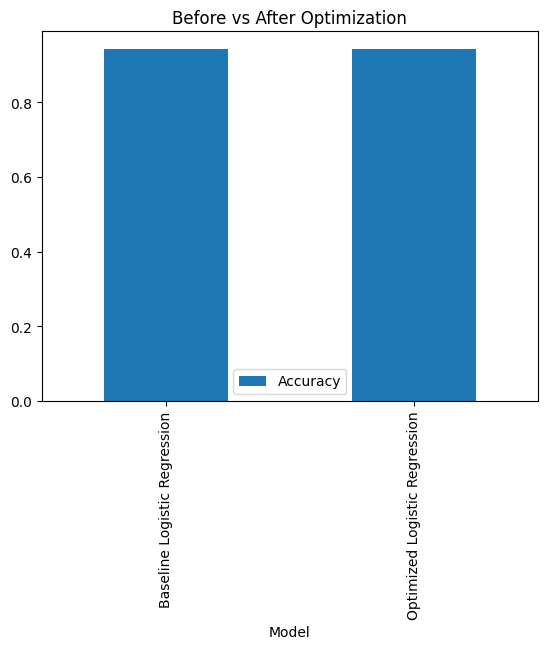

In [34]:
comparison.plot(

    x="Model",

    y="Accuracy",

    kind="bar"

)

plt.title(
    "Before vs After Optimization"
)

plt.savefig(
    "optimization_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Optimization Impact

The comparison graph shows that model accuracy remained unchanged after optimization. This confirms that the original model parameters were already suitable for the dataset and that further tuning produced no measurable improvement in accuracy.

# Cross Validation

In [35]:
cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5

)

print(
    "Cross Validation Scores:"
)

print(
    cv_scores
)

print(
    "Average CV Score:",
    cv_scores.mean()
)

Cross Validation Scores:
[0.95714286 0.98571429 0.95714286 0.95714286 0.98571429]
Average CV Score: 0.9685714285714286


### Cross-Validation Interpretation

The optimized Logistic Regression model achieved cross-validation scores ranging from approximately 95.71% to 98.57%, with an average cross-validation accuracy of 96.86%.

The relatively small variation between folds indicates that the model performs consistently across different subsets of the dataset. This demonstrates strong stability and suggests that the model is capable of generalizing well to unseen customer records.

The cross-validation results further validate the effectiveness of the selected model configuration and provide additional confidence that the observed performance is reliable rather than dependent on a single train-test split.


# Feature Importance

(Logistic Regression coefficients)

In [36]:
importance = pd.DataFrame({

    "Feature":df.columns[1:7],

    "Coefficient":best_model.coef_[0]

})

importance

,Feature,Coefficient
0,Monthly_Spend,-0.054593
1,Support_Tickets,0.217074
2,Contract_Length,0.199276
3,Service_Usage,-0.034943
4,Customer_Satisfaction,-0.156830
5,Renewal_History,-0.087629


### Feature Importance Interpretation

The feature coefficients indicate the relative influence of each variable on client retention prediction. Features with larger coefficients contribute more strongly to the model's decision-making process.

# Feature Importance Graph

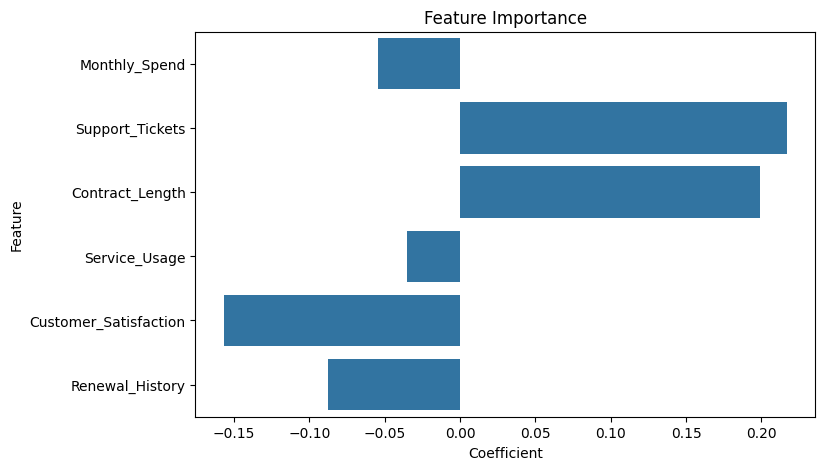

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Coefficient",

    y="Feature"

)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Business Factor Analysis

The feature importance visualization highlights the most influential customer-related factors affecting retention outcomes. Understanding these factors can help organizations improve retention strategies and customer engagement.

# Learning Curve


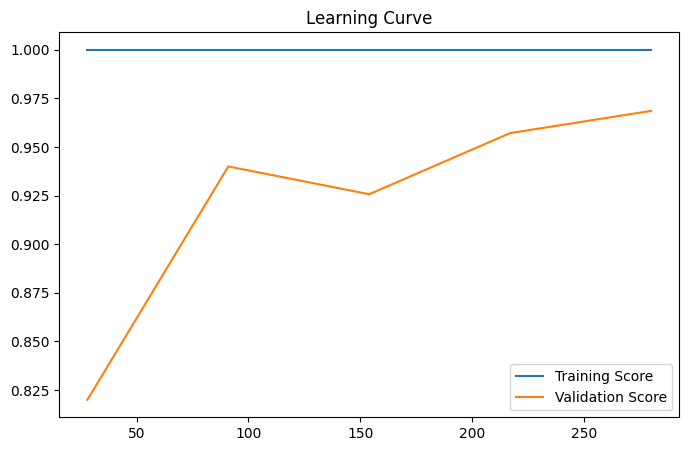

In [38]:
train_sizes, train_scores, test_scores = learning_curve(

    best_model,

    X,

    y,

    cv=5

)

train_mean = train_scores.mean(
    axis=1
)

test_mean = test_scores.mean(
    axis=1
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,
    label="Validation Score"
)

plt.legend()

plt.title(
    "Learning Curve"
)

plt.savefig(
    "learning_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Learning Curve Interpretation

The learning curve shows that the Logistic Regression model achieved perfect training performance while maintaining consistently high validation scores across different training set sizes.

As the amount of training data increased, the validation score improved and gradually approached the training score. This indicates that the model is learning meaningful patterns from the dataset and generalizing effectively to unseen data.

The relatively small gap between the final training and validation scores suggests that the model is not experiencing significant overfitting or underfitting. Overall, the learning curve demonstrates stable learning behavior and strong predictive performance.


### Overfitting and Underfitting Analysis

The learning curve indicates that the model is well-balanced. While the training score remains at 100%, the validation score reaches approximately 97% and continues to improve as more data becomes available.

The small difference between training and validation performance suggests that the model generalizes well and does not suffer from severe overfitting. Similarly, the high validation performance confirms that the model is not underfitting the dataset.

Therefore, the Logistic Regression model demonstrates strong stability, reliability, and generalization capability for client retention prediction.


# Confusion Matrix

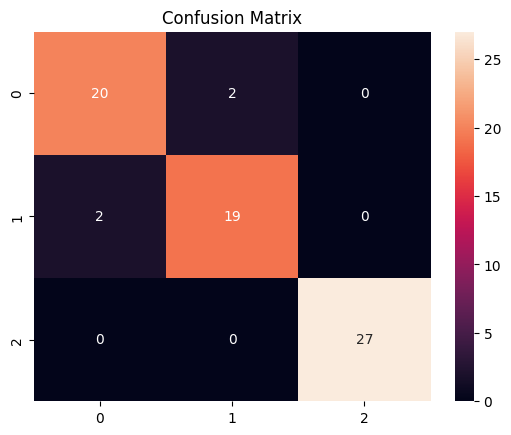

In [39]:
cm = confusion_matrix(
    y_test,
    optimized_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [40]:
# Download Files
from google.colab import files

files.download("optimization_comparison.png")

files.download("feature_importance.png")

files.download("learning_curve.png")

files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project successfully optimized and validated a Logistic Regression model for client retention prediction using GridSearchCV and cross-validation techniques.

The baseline model achieved an accuracy of 94.29%, and the optimized model achieved the same accuracy. While hyperparameter tuning did not increase the prediction accuracy, it played an important role in validating the model configuration and confirming that the baseline model was already performing near its optimal level for the current dataset.

Furthermore, the average cross-validation score of 96.86% demonstrated strong model consistency and generalization capability across multiple data partitions. The learning curve analysis also indicated balanced learning behavior without significant overfitting or underfitting.

Overall, the project highlights that model optimization is not only used to improve accuracy but also to verify model reliability, stability, and parameter effectiveness. The final model provides a dependable solution for customer retention prediction and demonstrates the practical value of machine learning in business analytics and customer relationship management.
